#import data and dependo

In [1]:
from linecache import cache
from random import shuffle

import pandas as pd
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True) #bringing tensorflow

for gpu in gpus:
    print(gpu)

import tensorflow_datasets as tfds

ds, info = tfds.load(
    'fashion_mnist',
    split='train',
    with_info=True
)
print(info)
import tensorflow_datasets as tfds
ds = tfds.load('fashion_mnist', split='train')
print("loaded")

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='/Users/timichtimovich/tensorflow_datasets/fashion_mnist/3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DB

In [2]:
import tensorflow_datasets as tfds #brinign tensorflow datasests for fashion mnst
from matplotlib import pyplot as plt #brining in matplotlib for viz stuff
ds = tfds.load('fashion_mnist', split='train') #use tensorflow datasets api to bring in data source

2026-03-23 04:23:41.733446: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2026-03-23 04:23:41.737880: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


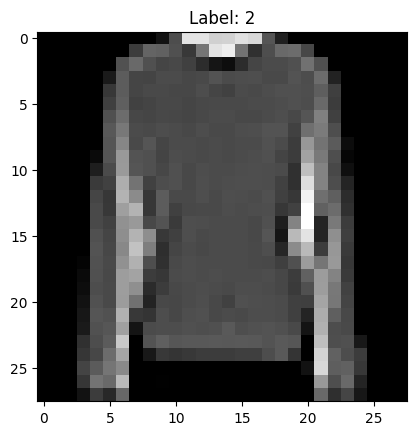

In [1]:
import tensorflow_datasets as tfds
from matplotlib import pyplot as plt

ds = tfds.load(
    'fashion_mnist',
    split='train',
    shuffle_files=False
)

sample = next(iter(tfds.as_numpy(ds)))
plt.imshow(sample['image'].squeeze(), cmap='gray')
plt.title(f"Label: {sample['label']}")
plt.show()

In [2]:
#viz data and build dataset
import numpy as np
#to do data transform
dataiterator = ds.as_numpy_iterator() #setup connection iterator
dataiterator.next() # getting data out of pipeline

{'image': array([[[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [ 18],
         [ 77],
         [227],
         [227],
         [208],
         [210],
         [225],
         [216],
         [ 85],
         [ 32],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0]],
 
        [[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [ 61],
         [100],
         [ 97],
         [ 80],
         [ 57],
         [117],
         [227],
         [238],
         [115],
         [ 49],
         [ 78],
         [106],
         [108],
         [ 71],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0]],
 
        [[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         

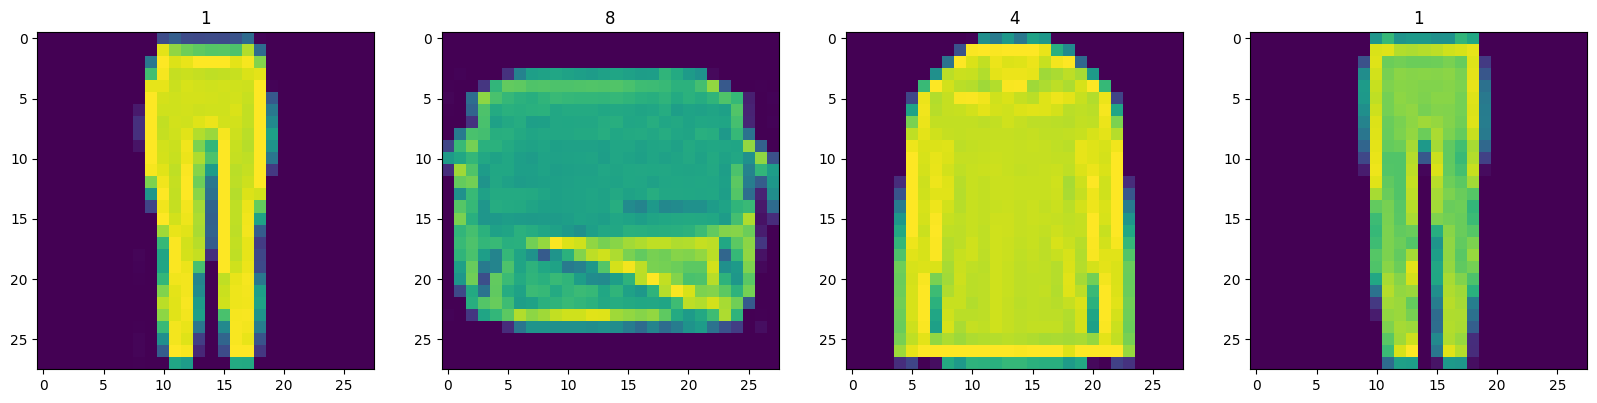

In [3]:

fig, ax = plt.subplots(ncols=4, figsize=(20,20))
#loop four times and get images
for idx in range(4):
    #grab image and plot it
    sample = dataiterator.next()
    #plotting image
    ax[idx].imshow(np.squeeze(sample['image']))
    ax[idx].title.set_text(sample['label'])

In [4]:
def scale_images(data):
    image = data['image']
    return image/255
#scale and return images only

In [6]:
#map
#cache
#shuffle
#batch
#prefetch

# #reload the dataset
# ds = tfds.load('fashion_mnist', split='train')
# # running the dataset through the scale_images preprocessing step
# ds = ds.map(scale_images)
# # cache the dataset for that batch
# ds = ds.cache()
# # shuffle it up
# ds = ds.shuffle(6000)
# #batch into 128 images per sample
# ds = ds.batch(128)
# # reduces the likelihood of bottlenecking
# ds = ds.prefetch(64)
ds = tfds.load("fashion_mnist", split="train")
ds = ds.map(scale_images, num_parallel_calls=tf.data.AUTOTUNE)
ds = ds.cache()
ds = ds.shuffle(60000)
ds = ds.batch(128)
ds = ds.prefetch(tf.data.AUTOTUNE)

NameError: name 'tf' is not defined

In [7]:
print(ds.element_spec)

{'image': TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}


In [8]:
# bring in the sequential api for the generator and discriminator
from tensorflow.keras.models import Sequential
#bring layers for the neural network
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Reshape, LeakyReLU, Dropout, UpSampling2D


In [9]:
def build_generator():
    model = Sequential()

    model.add(Dense(7 * 7 * 128, input_shape=(128,)))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Reshape((7, 7, 128)))

    model.add(UpSampling2D())
    model.add(Conv2D(128, 5, padding="same"))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(UpSampling2D())
    model.add(Conv2D(128, 5, padding="same"))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Conv2D(128, 4, padding="same"))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Conv2D(128, 4, padding="same"))
    model.add(LeakyReLU(negative_slope=0.2))

    model.add(Conv2D(1, 4, padding="same", activation="sigmoid"))
    return model


In [10]:
generator = build_generator()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,155,137 (8.22 MB)

 Trainable params: 2,155,137 (8.22 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
img = generator.predict(np.random.randn(4,128,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


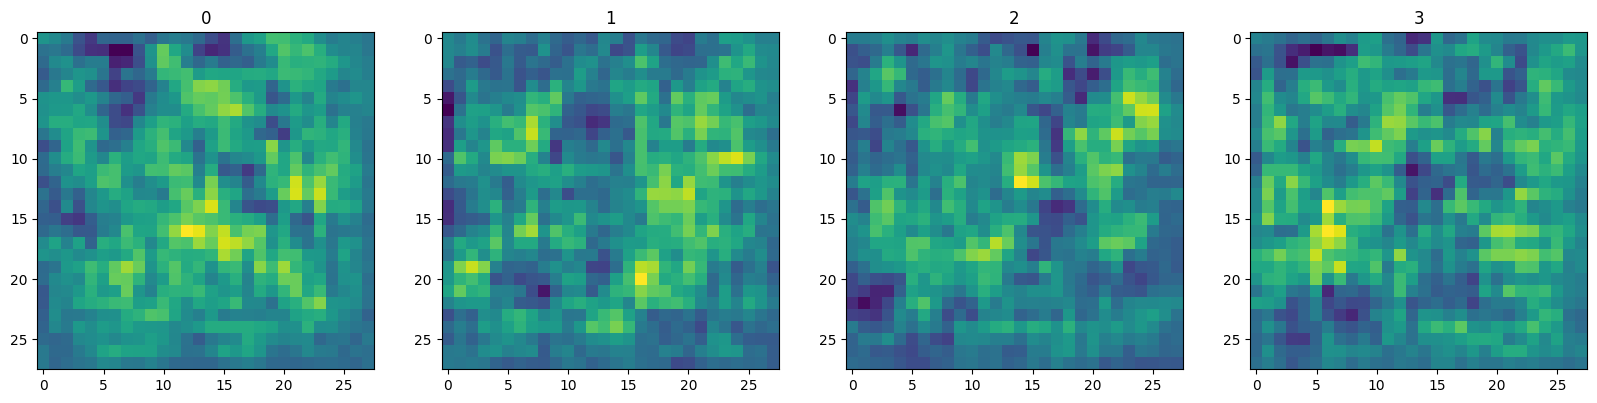

In [13]:
#generate new fashion
img = generator.predict(np.random.randn(4,128,1))
#setup subplot formatting
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
#loop 4 times and get images
for idx, img in enumerate(img):
    #plot image using a specific subplot
    ax[idx].imshow(np.squeeze(img))
    #append image label as the plot title
    ax[idx].title.set_text(idx)

In [14]:
def build_discriminator():
    model = Sequential()

    model.add(Conv2D(32, 5, input_shape=(28, 28, 1)))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.4))

    model.add(Conv2D(64, 5))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.4))

    model.add(Conv2D(128, 5))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.4))

    model.add(Conv2D(256, 5))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.4))

    model.add(Flatten())
    model.add(Dropout(0.4))
    model.add(Dense(1, activation="sigmoid"))

    return model

In [15]:
# discriminator = build_discriminator()
# discriminator.summary()
generator = build_generator()
discriminator = build_discriminator()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
import tensorflow as tf
generator(tf.random.normal((1, 128)))
discriminator(tf.random.normal((1, 28, 28, 1)))

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.4845594]], dtype=float32)>

In [18]:
#Adam is going to be the optimizer for both
from tensorflow.keras.optimizers import Adam
#binary cross entropy is going to be the loss for both
from tensorflow.keras.losses import BinaryCrossentropy
g_opt = Adam(learning_rate=0.0001)
d_opt = Adam(learning_rate=0.00001)
g_loss_fn = BinaryCrossentropy()
d_loss_fn = BinaryCrossentropy()

In [19]:
#Importing the base model class to subclass our training step
import tensorflow as tf
from tensorflow.keras.models import Model
tf.random.normal((6,128,1))

<tf.Tensor: shape=(6, 128, 1), dtype=float32, numpy=
array([[[-0.54171413],
        [ 0.6067667 ],
        [ 0.3529603 ],
        [-1.1850969 ],
        [ 0.18670213],
        [-0.6045412 ],
        [-0.02400394],
        [-0.6865357 ],
        [ 0.21395202],
        [-0.81408006],
        [-0.2817674 ],
        [-0.79747033],
        [ 1.6359872 ],
        [ 0.01474908],
        [-0.22381946],
        [-0.11787089],
        [ 1.8213863 ],
        [ 0.48465225],
        [-0.42500916],
        [-1.4850587 ],
        [-1.0920484 ],
        [ 0.81826055],
        [ 0.23266591],
        [-0.49993318],
        [-0.22065233],
        [ 0.36093545],
        [-1.3311366 ],
        [ 1.0634513 ],
        [ 0.13229775],
        [-0.33021042],
        [-0.58209264],
        [ 0.24798836],
        [-1.6920872 ],
        [ 0.5371997 ],
        [ 1.3425163 ],
        [ 0.6407079 ],
        [ 1.0083877 ],
        [-1.742557  ],
        [ 0.84362304],
        [-0.7985466 ],
        [-1.9237746 ],
    

In [20]:
class FashionGAN(Model):
    def __init__(self, generator, discriminator, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.generator = generator
        self.discriminator = discriminator

    def compile(self, g_opt, d_opt, g_loss_fn, d_loss_fn, *args, **kwargs):
        super().compile(*args, **kwargs)
        self.g_opt = g_opt
        self.d_opt = d_opt
        self.g_loss_fn = g_loss_fn
        self.d_loss_fn = d_loss_fn

    def train_step(self, data):
        x, y, sample_weight = tf.keras.utils.unpack_x_y_sample_weight(data)
        real_images = x

        batch_size = tf.shape(real_images)[0]

        # -----------------
        # Train discriminator
        # -----------------
        random_latent_vectors = tf.random.normal((batch_size, 128))

        with tf.GradientTape() as d_tape:
            fake_images = self.generator(random_latent_vectors, training=True)

            yhat_real = self.discriminator(real_images, training=True)
            yhat_fake = self.discriminator(fake_images, training=True)

            yhat_realfake = tf.concat([yhat_real, yhat_fake], axis=0)
            y_realfake = tf.concat(
                [tf.ones_like(yhat_real), tf.zeros_like(yhat_fake)],
                axis=0
            )

            d_loss = self.d_loss_fn(y_realfake, yhat_realfake)

        dgrad = d_tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_opt.apply_gradients(zip(dgrad, self.discriminator.trainable_variables))

        # -----------------
        # Train generator
        # -----------------
        random_latent_vectors = tf.random.normal((batch_size, 128))

        with tf.GradientTape() as g_tape:
            generated_images = self.generator(random_latent_vectors, training=True)
            predicted_labels = self.discriminator(generated_images, training=True)
            g_loss = self.g_loss_fn(tf.ones_like(predicted_labels), predicted_labels)

        ggrad = g_tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_opt.apply_gradients(zip(ggrad, self.generator.trainable_variables))

        return {"d_loss": d_loss, "g_loss": g_loss}

# class FashionGAN(Model):
#     def __init__(self, generator, discriminator, *args, **kwargs):
#         #pass thorugh args an dkwargs to base class
#         super().__init__(*args, **kwargs)
#         # create attributes for gen and disc
#         self.generator = generator
#         self.discriminator = discriminator
#     def compile(self, g_opt, d_opt, g_loss, d_loss, *args, **kwargs):
#         #compile with base class
#         super().compile(*args, **kwargs)
#
#         #create attributes for losses and optimizers
#         self.g_opt = g_opt
#         self.d_opt = d_opt
#         self.g_loss = g_loss
#         self.d_loss = d_loss
#     def train_step(self, batch):
#         real_images = batch
#         batch_size = tf.shape(real_images)[0]
#
#         random_latent_vectors = tf.random.normal((batch_size, 128))
#         fake_images = self.generator(random_latent_vectors, training=True)
#
#         with tf.GradientTape() as d_tape:
#             yhat_real = self.discriminator(real_images, training=True)
#             yhat_fake = self.discriminator(fake_images, training=True)
#             yhat_realfake = tf.concat([yhat_real, yhat_fake], axis=0)
#
#             y_realfake = tf.concat(
#                 [tf.ones_like(yhat_real), tf.zeros_like(yhat_fake)],
#                 axis=0
#             )
#
#             d_loss = self.d_loss_fn(y_realfake, yhat_realfake)
#
#         dgrad = d_tape.gradient(d_loss, self.discriminator.trainable_variables)
#         self.d_opt.apply_gradients(zip(dgrad, self.discriminator.trainable_variables))
#
#         random_latent_vectors = tf.random.normal((batch_size, 128))
#
#         with tf.GradientTape() as g_tape:
#             generated_images = self.generator(random_latent_vectors, training=True)
#             predicted_labels = self.discriminator(generated_images, training=True)
#             g_loss = self.g_loss_fn(tf.ones_like(predicted_labels), predicted_labels)
#
#         ggrad = g_tape.gradient(g_loss, self.generator.trainable_variables)
#         self.g_opt.apply_gradients(zip(ggrad, self.generator.trainable_variables))
#
#         return {"d_loss": d_loss, "g_loss": g_loss}
#     # def train_step(self, batch):
#     #     #get the data
#     #     real_images = batch
#     #     fake_images = self.generator(tf.random.normal((128, 128, 1)), training=False)
#     #     #Train discriminator
#     #     with tf.GradientTape() as d_tape:
#     #         #Pass the real and fake images to discriminator model
#     #         yhat_real = self.discriminator(real_images, training=True)
#     #         yhat_fake = self.discriminator(fake_images, training=True)
#     #         yhat_realfake = tf.concat([yhat_real, yhat_fake], axis = 0)
#     #         #Create labels for real and fake images
#     #         y_realfake = tf.concat([tf.zeros_like(yhat_real), tf.ones_like(yhat_fake)], axis=0)
#     #         #add some noise to the outputs
#     #         noise_real = 0.15*tf.random.uniform(tf.shape(yhat_real))
#     #         noise_fake = -0.15*tf.random.uniform(tf.shape(yhat_fake))
#     #         y_realfake += tf.concat([noise_real, noise_fake], axis=0)
#     #         #calculate loss BINARYCROSS
#     #         total_d_loss = self.d_loss(y_realfake, yhat_realfake)
#     #     #apply backpropagation - nn learn
#     #     dgrad = d_tape.gradient(total_d_loss, self.discriminator.trainable_variables)
#     #     self.d_opt.apply_gradients(zip(dgrad, self.discriminator.trainable_variables))
#
#     #     #Train the generator
#     #     with tf.GradientTape() as g_tape:
#     #         #generate some new images
#     #         gen_images = self.generator(tf.random.normal((128,128,1)), training=True)
#
#     #         #create the predicted labels
#     #         predicted_labels = self.discriminator(gen_images, training=False)
#
#     #         # calculate loss = fake out the discriminator to trick to training
#     #         total_g_loss = self.g_loss(tf.zeros_like(predicted_labels), predicted_labels)
#     #     #apply backprop
#     #     ggrad = g_tape.gradient(total_g_loss, self.generator.trainable_variables)
#     #     self.g_opt.apply_gradients(zip(ggrad, self.generator.trainable_variables))
#     #     return {"d_loss": total_d_loss, "g_loss": total_g_loss}

In [23]:
fashgan = FashionGAN(generator, discriminator)
fashgan.compile(g_opt, d_opt, g_loss_fn, d_loss_fn)

In [84]:
# @tf.function
#     def train_step

In [22]:
#create instance of subclassed model
fashgan = FashionGAN(generator, discriminator)

#compile the model
fashgan.compile(g_opt, d_opt, g_loss, d_loss)

NameError: name 'g_loss' is not defined

In [97]:
import os
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.callbacks import Callback

class ModelMonitor(Callback):
    def __init__(self, num_img=3, latent_dim=128):
        self.num_img = num_img
        self.latent_dim = latent_dim

    def on_epoch_end(self, epoch, logs=None):
        random_latent_vectors = tf.random.uniform((self.num_img, self.latent_dim, 1))
        generated_images = self.model.generator(random_latent_vectors)
        generated_images *= 255
        generated_images.numpy()
        for i in range(self.num_img):
            img = array_to_img(generated_images[i])
            img.save(os.path.join('images', f'generated_img_{epoch}_{i}.png'))

In [24]:
hist = fashgan.fit(ds, epochs=1)

TypeError: Expected any non-tensor type, but got a tensor instead.

In [ ]:
plt.suptitle('Loss')
plt.plot(hist.history['d_loss'], label='d_loss')
plt.plot(hist.history['g'], label='g_loss')
plt.legend()
plt.show()

In [ ]:
#generate images
generator.load_weights(os.path.join('archive', 'generatormodel.h5'))
imgs = generator.predict(tf.random.normal((16, 128,1)))
fig, ax = plt.subplots(ncols=4, nrows=4, figsize=(10,10))
for r in range(4):
    for c in range(4):
        ax[r][c].imshow(imgs[(r+1)*(c+1)-1])

In [ ]:
generator.save('generator.h5')
discriminator.save('discriminator.h5')